**Experiment 7**

In [1]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 1.6 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt



# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [3]:
# Cell 3 — Dataset: Fashion-MNIST + loaders
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print("train:", len(train_ds), "test:", len(test_ds))


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.0MB/s]

train: 60000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients (DISJOINT, recommended for paper)
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20      # 200 public points (try 30 => 300)
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
            for i in range(num_clients)]

clients = build_iid_clients_from_indices(avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 59800
NUM_CLIENTS: 5980 | samples/client: 10 | clients/round: 100
q = 0.016722408026755852


In [5]:
# Cell 6 — Model + evaluation
class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


In [6]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t*t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a*b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out


In [7]:
# Cell 8 — Local client update (SGD) returns delta = (local - global)
loss_fn = nn.CrossEntropyLoss()

def client_update(global_model, client_indices, lr, momentum, local_epochs=1, batch_size=10):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(Subset(train_ds, client_indices),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())
    return delta


In [9]:
# Cell 9 — DP accounting (RDP) + sigma search (Opacus-version-proof)
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    # Some versions accept kwargs, others positional; support both.
    try:
        return rdp_analysis.compute_rdp(q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders)
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(orders=orders, rdp=rdp, delta=delta)
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sig_sel = sel_factor * sig_rel
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor*sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [10]:
# Cell 10 — ALIE attack helpers (constant-z, consistent across f)
# Purpose: ALIE strength does NOT change with Byzantine fraction.

@torch.no_grad()
def alie_attack_from_honest_constz(honest_updates, byz_count, z=2.0, direction=-1.0):
    """
    Returns byz_count malicious updates where:
        mal = mu + direction * z * std   (coordinate-wise)
    z is constant (same for all f).
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build ALIE.")

    P = len(honest_updates[0])
    mal = []
    for j in range(P):
        stacked = torch.stack([u[j] for u in honest_updates], dim=0)
        mu = stacked.mean(dim=0)
        sd = stacked.std(dim=0, unbiased=False) + 1e-12
        mal.append(mu + float(direction) * float(z) * sd)

    mal = [t.detach() for t in mal]
    return [[t.clone() for t in mal] for _ in range(byz_count)]


In [11]:
# Cell 12 — AG-PTR (FINAL, self-contained): single-τ PTR with anchors {a_pub, 0}


def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(pub_batch_size, len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD step (public_epochs)
      - anchor = pub_scale * delta_pub
    Returns: list length R, each element is list-of-tensors
    """
    rng = np.random.RandomState(seed)
    anchors = []
    for r in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    """Average a list of anchors (each anchor is list-of-tensors)."""
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 # public anchor construction
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 # ALIE attack (constant-z)
                 alie_direction=-1.0, alie_z=2.0,
                 # policy
                 allow_zero=False):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)               # IMPORTANT (works even if you changed NUM_CLIENTS)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)

    accept = 0

    for t in tqdm(range(rounds), desc=f"AG-PTR f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        # ---- Byzantine updates (ALIE constant-z) ----
        byz_updates = alie_attack_from_honest_constz(
            honest_updates, b, z=alie_z, direction=alie_direction
        ) if b > 0 else []

        # ---- rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        kk = 0
        for j in range(clients_per_round):
            if j in byz_pos:
                deltas[j] = byz_updates[kk]; kk += 1

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0); n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        # single τ (matches your LaTeX)
        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        for j in range(len(sum_offsets)):
            sum_offsets[j].add_(torch.randn_like(sum_offsets[j]) * (float(sigma_rel) * float(rho)))

        mean_update = [a + (so / m_hat) for a, so in zip(a_star, sum_offsets)]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    return acc, accept / rounds

    # --- EXP 7 (ii) Anchored-mean-only (NO GATE) ---
def train_anchored_mean_only(seed, eps_total, byz_frac,
                             sigma_release, delta=1e-5,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             rho=0.79,
                             # public anchor construction
                             R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                             # ALIE attack (constant-z)
                             alie_direction=-1.0, alie_z=2.0):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)

    for t in tqdm(range(rounds), desc=f"AnchoredMeanOnly f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        # ---- Byzantine updates (ALIE constant-z) ----
        byz_updates = alie_attack_from_honest_constz(
            honest_updates, b, z=alie_z, direction=alie_direction
        ) if b > 0 else []

        # ---- Rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        kk = 0
        for j in range(clients_per_round):
            if j in byz_pos:
                deltas[j] = byz_updates[kk]; kk += 1

        # ---- Anchored mean around a_pub, using ALL clients (NO GATE) ----
        sum_offsets = zero_like_params(model)
        for dlt in deltas:
            offset = sub_list(dlt, a_pub)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        # DP release noise
        for j in range(len(sum_offsets)):
            sum_offsets[j].add_(torch.randn_like(sum_offsets[j]) * (float(sigma_release) * float(rho)))

        mean_update = [a + (so / float(clients_per_round)) for a, so in zip(a_pub, sum_offsets)]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    return acc


# --- EXP 7 (iii) Gate + GLOBAL CLIPPED MEAN (NO ANCHORED MEAN) ---
def train_ag_ptr_gate_global_clipped_mean(seed, eps_total, byz_frac,
                                          sigma_sel, sigma_rel, delta=1e-5,
                                          rounds=30, local_epochs=10, batch_size=10,
                                          lr0=0.125, lr_decay=0.99, momentum=0.5,
                                          tau=60,
                                          clip_C=0.79,   # IMPORTANT: set = rho for clean ablation
                                          # public anchor construction
                                          R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                                          # ALIE attack
                                          alie_direction=-1.0, alie_z=2.0,
                                          # policy
                                          allow_zero=False):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)

    accept = 0

    for t in tqdm(range(rounds), desc=f"Gate+GlobalClipMean f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        byz_updates = alie_attack_from_honest_constz(
            honest_updates, b, z=alie_z, direction=alie_direction
        ) if b > 0 else []

        # ---- Rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        kk = 0
        for j in range(clients_per_round):
            if j in byz_pos:
                deltas[j] = byz_updates[kk]; kk += 1

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0); n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue
        if float(noisy_winner) < float(tau):
            continue

        accept += 1

        # ---- Release: GLOBAL CLIPPED MEAN over selected cluster ----
        sum_update = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            nrm = float(l2_norm_list(dlt).item())
            scale = min(1.0, float(clip_C) / (nrm + 1e-12))
            add_scaled_list_(sum_update, dlt, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (float(sigma_rel) * float(clip_C)))

        mean_update = [u / m_hat for u in sum_update]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    return acc, accept / rounds

In [12]:
#cell 14 sm0ke test
seed = 0
eps_total = 2.0
delta = 1e-5
f = 0.2

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ALIE_Z = 2.0
ALIE_DIR = -1.0

# Shared AG-PTR params
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

q = CLIENTS_PER_ROUND / len(clients)

# (i) and (iii): two-mechanism sigmas (gate + release)
sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
print("Gate variants sigma_sel/sigma_rel:", sigma_sel, sigma_rel,
      "eps≈", epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta))

# (ii): single-mechanism sigma (release only)
sigma_am = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
print("Anchored-mean-only sigma:", sigma_am,
      "eps≈", epsilon_from_sigma_single(sigma_am, q, ROUNDS, delta))

acc_full, ar_full = train_ag_ptr(
    seed, eps_total, f,
    sigma_sel, sigma_rel, delta=delta,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
    lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
    rho=RHO, tau=TAU,
    R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
    alie_direction=ALIE_DIR, alie_z=ALIE_Z,
    allow_zero=False
)

acc_am = train_anchored_mean_only(
    seed, eps_total, f,
    sigma_release=sigma_am, delta=delta,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
    lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
    rho=RHO,
    R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
    alie_direction=ALIE_DIR, alie_z=ALIE_Z
)

acc_gate_clip, ar_gate_clip = train_ag_ptr_gate_global_clipped_mean(
    seed, eps_total, f,
    sigma_sel=sigma_sel, sigma_rel=sigma_rel, delta=delta,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
    lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
    tau=TAU,
    clip_C=RHO,   # keep clip_C=rho for clean ablation
    R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
    alie_direction=ALIE_DIR, alie_z=ALIE_Z,
    allow_zero=False
)

print("\nFull AG-PTR acc:", acc_full, "accept_rate:", ar_full)
print("AnchoredMeanOnly acc:", acc_am)
print("Gate+GlobalClipMean acc:", acc_gate_clip, "accept_rate:", ar_gate_clip)

Gate variants sigma_sel/sigma_rel: 1.6087871355020584 0.8043935677510292 eps≈ 1.9999999999999973
Anchored-mean-only sigma: 0.804078106574686 eps≈ 1.9999999999999978


Gate+GlobalClipMean f=20%: 100%|██████████| 5/5 [00:00<00:00,  5.34it/s]



Full AG-PTR acc: 0.516 accept_rate: 1.0
AnchoredMeanOnly acc: 0.4149
Gate+GlobalClipMean acc: 0.5155 accept_rate: 1.0


Gate variants sigma_sel/sigma_rel: 1.965902445173369 0.9829512225866845 achieved eps≈ 1.999999999999998
Anchored-mean-only sigma: 0.9723217465539842 achieved eps≈ 1.9999999999999973
Params: rho=0.79, tau=55, R_pub_avg=8, pub_batch=20, pub_scale=0.1
Attacker: ALIE const-z=2.0, dir=-1.0


Gate+GlobalClipMean f=60%: 100%|██████████| 180/180 [01:36<00:00,  1.87it/s]


Saved exp7_seedwise.csv
Saved exp7_summary.csv


,f,seed_mean,seed_std,full_agptr_acc_mean,full_agptr_acc_std,full_agptr_accept_rate_mean,full_agptr_accept_rate_std,anchored_mean_only_acc_mean,anchored_mean_only_acc_std,gate_global_clip_acc_mean,gate_global_clip_acc_std,gate_global_clip_accept_rate_mean,gate_global_clip_accept_rate_std
0,0.00,1.0,1.0,0.782033,0.003547,0.722222,0.034694,0.821767,0.005615,0.784000,0.002138,0.735185,0.035717
1,0.10,1.0,1.0,0.766367,0.007004,0.759259,0.022453,0.791633,0.011652,0.772167,0.000862,0.711111,0.057735
2,0.20,1.0,1.0,0.758167,0.004416,0.588889,0.052997,0.689033,0.045465,0.755633,0.000208,0.577778,0.027778
3,0.30,1.0,1.0,0.718667,0.056497,0.401852,0.109760,0.503700,0.033572,0.746600,0.013353,0.300000,0.101379
4,0.40,1.0,1.0,0.705700,0.045321,0.250000,0.033793,0.287100,0.012805,0.711333,0.048327,0.157407,0.067205
5,0.49,1.0,1.0,0.599367,0.015531,0.029630,0.003208,0.325067,0.046796,0.597867,0.015063,0.029630,0.003208
6,0.60,1.0,1.0,0.120633,0.038818,0.005556,0.000000,0.237733,0.120931,0.119733,0.039981,0.005556,0.000000


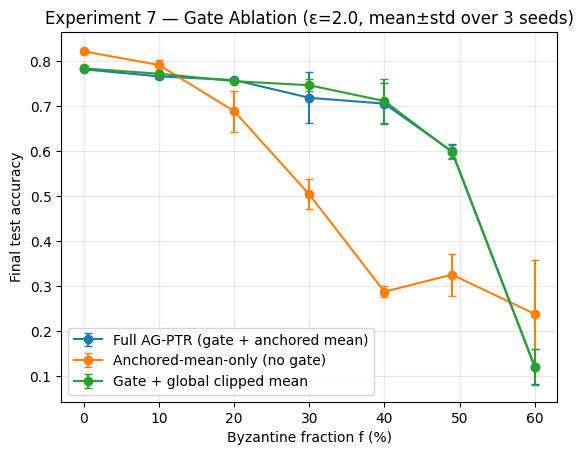

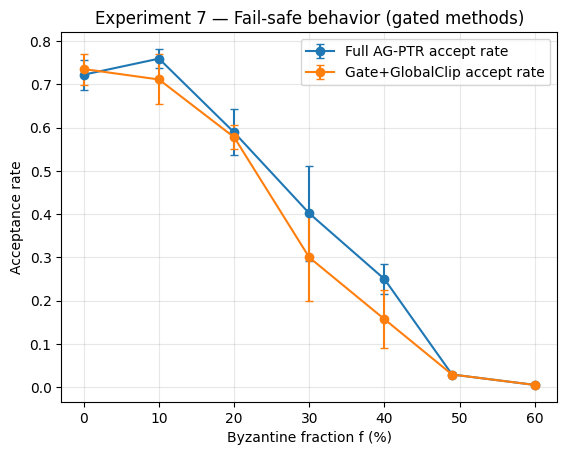

In [13]:
# cell 15 full run
seed_list = [0, 1, 2]
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 180
LOCAL_EPOCHS = 10
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ALIE_Z = 2.0
ALIE_DIR = -1.0

# Shared anchor params
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

q = CLIENTS_PER_ROUND / len(clients)

# (i) and (iii): gate+release sigmas
sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_gate = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

# (ii): release-only sigma
sigma_am = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
eps_am = epsilon_from_sigma_single(sigma_am, q, ROUNDS, delta)

print("Gate variants sigma_sel/sigma_rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_gate)
print("Anchored-mean-only sigma:", sigma_am, "achieved eps≈", eps_am)
print(f"Params: rho={RHO}, tau={TAU}, R_pub_avg={R_PUB_AVG}, pub_batch={PUB_BATCH}, pub_scale={PUB_SCALE}")
print(f"Attacker: ALIE const-z={ALIE_Z}, dir={ALIE_DIR}")

rows = []

for seed in seed_list:
    for f in f_list:
        # (i) full AG-PTR
        acc_full, ar_full = train_ag_ptr(
            seed, eps_total, f,
            sigma_sel, sigma_rel, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            rho=RHO, tau=TAU,
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            allow_zero=False
        )

        # (ii) anchored-mean-only (no gate)
        acc_am = train_anchored_mean_only(
            seed, eps_total, f,
            sigma_release=sigma_am, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            rho=RHO,
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z
        )

        # (iii) gate + global clipped mean
        acc_gate_clip, ar_gate_clip = train_ag_ptr_gate_global_clipped_mean(
            seed, eps_total, f,
            sigma_sel=sigma_sel, sigma_rel=sigma_rel, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            tau=TAU,
            clip_C=RHO,  # keep clip_C=rho for clean ablation
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            allow_zero=False
        )

        rows.append({
            "seed": seed,
            "f": f,
            "full_agptr_acc": acc_full,
            "full_agptr_accept_rate": ar_full,
            "anchored_mean_only_acc": acc_am,
            "gate_global_clip_acc": acc_gate_clip,
            "gate_global_clip_accept_rate": ar_gate_clip
        })

df_seedwise = pd.DataFrame(rows)
df_seedwise.to_csv("exp7_seedwise.csv", index=False)
print("Saved exp7_seedwise.csv")

summary = df_seedwise.groupby("f").agg(["mean", "std"]).reset_index()
summary.columns = ["_".join([c for c in col if c]) for col in summary.columns.values]
summary = summary.rename(columns={"f_": "f"})
summary.to_csv("exp7_summary.csv", index=False)
print("Saved exp7_summary.csv")

display(summary)

# Plot accuracy vs f
f_pct = (summary["f"] * 100).tolist()

plt.figure()
plt.errorbar(f_pct, summary["full_agptr_acc_mean"], yerr=summary["full_agptr_acc_std"],
             marker="o", capsize=3, label="Full AG-PTR (gate + anchored mean)")
plt.errorbar(f_pct, summary["anchored_mean_only_acc_mean"], yerr=summary["anchored_mean_only_acc_std"],
             marker="o", capsize=3, label="Anchored-mean-only (no gate)")
plt.errorbar(f_pct, summary["gate_global_clip_acc_mean"], yerr=summary["gate_global_clip_acc_std"],
             marker="o", capsize=3, label="Gate + global clipped mean")
plt.xlabel("Byzantine fraction f (%)")
plt.ylabel("Final test accuracy")
plt.title(f"Experiment 7 — Gate Ablation (ε={eps_total}, mean±std over {len(seed_list)} seeds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot acceptance vs f (only gated methods)
plt.figure()
plt.errorbar(f_pct, summary["full_agptr_accept_rate_mean"], yerr=summary["full_agptr_accept_rate_std"],
             marker="o", capsize=3, label="Full AG-PTR accept rate")
plt.errorbar(f_pct, summary["gate_global_clip_accept_rate_mean"], yerr=summary["gate_global_clip_accept_rate_std"],
             marker="o", capsize=3, label="Gate+GlobalClip accept rate")
plt.xlabel("Byzantine fraction f (%)")
plt.ylabel("Acceptance rate")
plt.title("Experiment 7 — Fail-safe behavior (gated methods)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()